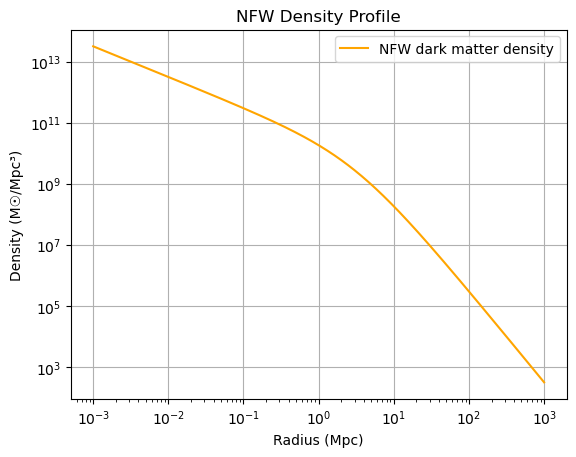

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.constants import G, c
from astropy.modeling.physical_models import NFW
import math
import numpy as np
from scipy.optimize import minimize

# properties of lensed quasar system DES J0408-5354
e_radius_arcs = 1.75
e_radius_rads = (e_radius_arcs * u.arcsec).to(u.rad).value
z_lens = 0.597
z_source = 2.375
log_mass_stellar = 11.49

# angular diameter distances from redshifts in meters
d_L = cosmo.angular_diameter_distance(z_lens).to(u.kpc).value
d_S = cosmo.angular_diameter_distance(z_source).to(u.kpc).value
d_LS = cosmo.angular_diameter_distance_z1z2(z_lens, z_source).to(u.kpc).value

e_radius_mpc = e_radius_rads * d_L

# Physical constants 
G = G.to('Mpc3 / (Msun s2)')
c = c.to('Mpc/s')


# Calculating enclosed mass within einstein radius
mass_enclosed = ((((c**2) / (4 * G)) * ((d_S * d_L) / d_LS) * (e_radius_rads**2))).value
log_mass_enclosed = np.log10(mass_enclosed)
log_mass_enclosed

# dark matter mass
log_mass_dm = np.log10(10**log_mass_enclosed - 10**log_mass_stellar)
log_mass_dm

def nfw_enclosed_mass(r_s, rho_s, r):
    """
    r_s = scale radius
    rho_s = scale density at r
    r = radial distance from center of halo
    """
    x = r / r_s
    return 4 * np.pi * rho_s * r_s**3 * (np.log(1 + x) - x / (1 + x))

def objective(params):
    log_rho_s, log_r_s = params
    rho_s = 10**log_rho_s
    r_s = 10**log_r_s
    mass_model = nfw_enclosed_mass(e_radius_mpc, rho_s, r_s)
    log_mass_model = np.log10(mass_model)
    return (log_mass_model - log_mass_dm)**2

# initial guesses
p0_log = [7, -0.5]  # log10(rho_s [Msun/Mpc³]), log10(r_s [Mpc])
bounds_log = [(5, 10), (-2, 0.5)] # ask how to adjust and ensure good fit

# fitting the model
result = minimize(objective, p0_log, bounds=bounds_log)
log_rho_s_fit, log_r_s_fit = result.x

rho_s_fit = 10**log_rho_s_fit # Msun/Mpc^3
r_s_fit = 10**log_r_s_fit # Mpc

def nfw_density(r, rho_s, r_s):
    x = r / r_s
    return rho_s / (x * (1 + x)**2)

r_values = np.logspace(-3, 3, 500)
density_values = nfw_density(r_values, rho_s_fit, r_s_fit)

plt.figure()
plt.plot(r_values, density_values, label="NFW dark matter density", color="orange")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Radius (Mpc)")
plt.ylabel("Density (M☉/Mpc³)")
plt.title("NFW Density Profile")
plt.legend()
plt.grid()

In [19]:
print(rho_s_fit)
print(r_s_fit)

10000000000.0
3.1622776601683795


In [15]:
# Known parameters
rho_s_true = 1e7  # Msun/Mpc^3
r_s_true = 0.2    # Mpc

# mock "observations"
mock_radius = 0.9  # Mpc
mock_mass = nfw_enclosed_mass(r_s_true, rho_s_true, mock_radius)
mock_log_mass_dm = np.log10(mock_mass)

# objective for test case
def test_objective(params):
    log_rho_s, log_r_s = params
    rho_s = 10**log_rho_s
    r_s = 10**log_r_s
    mass_model = nfw_enclosed_mass(r_s, rho_s, mock_radius)
    return (np.log10(mass_model) - mock_log_mass_dm)**2

# Fit to mock data
from scipy.optimize import minimize
p0_log = [7, -0.5]
bounds_log = [(5, 10), (-2, 1)]
result = minimize(test_objective, p0_log, bounds=bounds_log)
log_rho_s_fit, log_r_s_fit = result.x

print(f"True rho_s: {rho_s_true:.2e}, Fitted: {10**log_rho_s_fit:.2e}")
print(f"True r_s: {r_s_true:.2f}, Fitted: {10**log_r_s_fit:.2f}")


True rho_s: 1.00e+07, Fitted: 8.12e+06
True r_s: 0.20, Fitted: 0.22


Text(0.5, 1.0, 'Validation of NFW Fit')

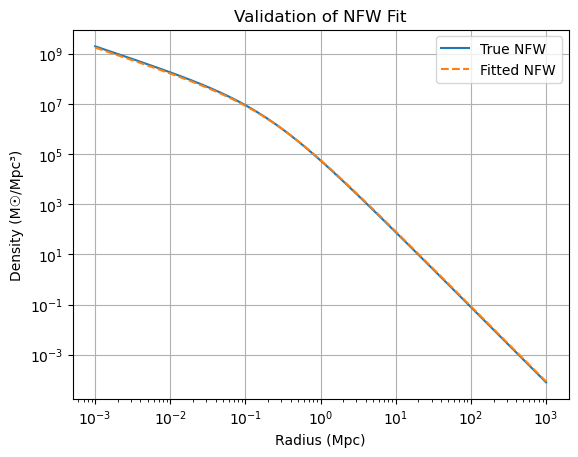

In [17]:
density_true = nfw_density(r_values, rho_s_true, r_s_true)
density_fit = nfw_density(r_values, 10**log_rho_s_fit, 10**log_r_s_fit)

plt.figure()
plt.plot(r_values, density_true, label="True NFW")
plt.plot(r_values, density_fit, '--', label="Fitted NFW")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Radius (Mpc)")
plt.ylabel("Density (M☉/Mpc³)")
plt.legend()
plt.grid()
plt.title("Validation of NFW Fit")